In [1]:
from __future__ import annotations

import sys, os
sys.path.append(os.path.abspath(".."))

# Данные

In [2]:
from torch_geometric.data import Dataset, Data
import torch
import numpy as np
import pandas as pd
from scipy import stats

вспомогательные функции для построения матрицы смежности

In [3]:
def pearson_matrix(df: pd.DataFrame) -> np.ndarray:
  """Корреляция Пирсона между всеми парами признаков."""
  return df.corr(method='pearson').values

def spearman_matrix(df: pd.DataFrame) -> np.ndarray:
  """Ранговая корреляция Спирмена (устойчива к выбросам)."""
  return df.corr(method='spearman').values

def mutual_info_matrix(df: pd.DataFrame) -> np.ndarray:
  """
  Нормированная взаимная информация (NMI) через оценку плотности.
  Симметрична, лежит в [0, 1].
  """
  n_features = df.shape[1]
  mi = np.zeros((n_features, n_features))
  arr = df.values.astype(np.float32)
  for i in range(n_features):
    for j in range(i + 1, n_features):
      # kernel-density оценка двумерной MI через корреляцию Спирмена
      # (быстрое приближение без sklearn)
      r, _ = stats.spearmanr(arr[:, i], arr[:, j])
      r = np.clip(r, -1 + 1e-9, 1 - 1e-9)
      nmi = abs(r) # приближение: |r| ≈ NMI для монотонных связей
      mi[i, j] = nmi
      mi[j, i] = nmi

  np.fill_diagonal(mi, 1.0)
  return mi

def partial_corr_matrix(df: pd.DataFrame) -> np.ndarray:
  """
  Частичная корреляция через обращение корреляционной матрицы.
  Показывает прямую связь между парой переменных при фиксации остальных.
  """
  corr = df.corr(method='pearson').values
  try:
    inv = np.linalg.pinv(corr)
    d = np.sqrt(np.diag(inv))
    partial = -inv / np.outer(d, d)
    np.fill_diagonal(partial, 1.0)
    return np.abs(partial)
  except np.linalg.LinAlgError:
    return np.abs(corr)

EDGE_STRATEGIES = {
  'pearson':      pearson_matrix,
  'spearman':     spearman_matrix,
  'mutual_info':  mutual_info_matrix,
  'partial_corr': partial_corr_matrix,
}

In [4]:
class PolyFilmDataset(Dataset):
  def __init__(
    self,
    df: pd.DataFrame,
    target_col: str = 'target',
    edge_strategy: str | list[str] = 'pearson',
    threshold: float = 0.3,
    top_k_edges_per_node: int | None = None,
    self_loops: bool = False,
    normalize_features: bool = True,
    feature_mean: pd.Series | None = None,
    feature_std: pd.Series | None = None,
    edge_index: torch.Tensor | None = None,
    edge_attr: torch.Tensor | None = None,
  ):
    super().__init__()

    self._feature_cols: list[str] = [c for c in df.columns if c != target_col]
    self._n_nodes: int = len(self._feature_cols)

    feature_df = df[self._feature_cols].copy().astype(np.float32)
    labels = df[target_col].values.astype(np.int64)

    if normalize_features:
      if feature_mean is None:
        self._mean = feature_df.mean()
      else:
        self._mean = feature_mean.reindex(self._feature_cols).astype(np.float32)

      if feature_std is None:
        self._std = feature_df.std().replace(0, 1)
      else:
        self._std = feature_std.reindex(self._feature_cols).replace(0, 1).astype(np.float32)

      feature_df = (feature_df - self._mean) / self._std
    else:
      self._mean = None
      self._std = None

    self._features: np.ndarray = feature_df.values
    self._labels: np.ndarray = labels

    if edge_index is not None and edge_attr is not None:
      self._edge_index = edge_index.clone().detach().long()
      self._edge_attr = edge_attr.clone().detach().float()
      return

    strategies = [edge_strategy] if isinstance(edge_strategy, str) else edge_strategy
    for s in strategies:
      if s not in EDGE_STRATEGIES:
        raise ValueError(
          f"Неизвестная стратегия '{s}'. "
          f"Доступные: {list(EDGE_STRATEGIES)}"
        )

    weight_matrices = [
      np.abs(EDGE_STRATEGIES[s](feature_df))
      for s in strategies
    ]

    combined: np.ndarray = np.mean(weight_matrices, axis=0)
    np.fill_diagonal(combined, 0.0)

    if top_k_edges_per_node is not None:
      src_list, dst_list = [], []
      for i in range(self._n_nodes):
        row = combined[i].copy()
        row[i] = 0.0
        candidates = np.flatnonzero(row >= threshold)
        if len(candidates) == 0:
          continue
        if len(candidates) > top_k_edges_per_node:
          best = np.argpartition(row[candidates], -top_k_edges_per_node)[-top_k_edges_per_node:]
          candidates = candidates[best]
        src_list.extend([i] * len(candidates))
        dst_list.extend(candidates.tolist())
      src = np.asarray(src_list, dtype=np.int64)
      dst = np.asarray(dst_list, dtype=np.int64)
    else:
      src, dst = np.where(combined >= threshold)

    edge_weights = combined[src, dst].astype(np.float32)

    if self_loops:
      loop_idx = np.arange(self._n_nodes)
      src = np.concatenate([src, loop_idx])
      dst = np.concatenate([dst, loop_idx])
      edge_weights = np.concatenate([edge_weights, np.ones(self._n_nodes)])

    self._edge_index: torch.Tensor = torch.tensor(
      np.stack([src, dst], axis=0), dtype=torch.long
    )
    self._edge_attr: torch.Tensor = torch.tensor(
      edge_weights,  dtype=torch.float32
    ).unsqueeze(1)

  def len(self) -> int:
    return len(self._labels)

  def get(self, idx: int) -> Data:
    """
    Возвращает граф для одного наблюдения.

    Граф:
    x          — (N_nodes, 1)  значения признаков для данного наблюдения
    edge_index — (2, E)        индексы рёбер (общие для всех графов)
    edge_attr  — (E, 1)        веса рёбер (общие для всех графов)
    y          — (1,)          бинарная метка
    """

    node_features = torch.tensor(
      self._features[idx], dtype=torch.float32
    ).unsqueeze(1)

    label = torch.tensor(self._labels[idx], dtype=torch.long)

    return Data(
      x             = node_features,
      edge_index    = self._edge_index,
      edge_attr     = self._edge_attr,
      y             = label,
      num_nodes     = self._n_nodes,
    )

  @property
  def num_node_features(self) -> int:
    return 1

  @property
  def num_classes(self) -> int:
    return 2

  @property
  def feature_names(self) -> list[str]:
    return self._feature_cols

  @property
  def feature_mean(self) -> pd.Series | None:
    return self._mean.copy() if self._mean is not None else None

  @property
  def feature_std(self) -> pd.Series | None:
    return self._std.copy() if self._std is not None else None

  @property
  def edge_index(self) -> torch.Tensor:
    return self._edge_index.clone()

  @property
  def edge_attr(self) -> torch.Tensor:
    return self._edge_attr.clone()

  @property
  def num_edges(self) -> int:
    return self._edge_index.shape[1]

  def __repr__(self) -> str:
    return (
      f"{self.__class__.__name__}("
      f"samples={self.len()}, "
      f"nodes={self._n_nodes}, "
      f"edges={self.num_edges})"
    )

# Модель

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.nn import (
  GATv2Conv,
  GraphNorm,
  global_add_pool,
  global_mean_pool,
  global_max_pool,
)
from torch_geometric.data import Batch

In [6]:
class GATBlock(nn.Module):
  """
  Один слой графового внимания с нормализацией и остаточным соединением.

  Parameters
  ----------
  in_channels : int
  out_channels : int      размерность выхода на голову (head)
  heads : int             число голов внимания
  dropout : float         вероятность dropout на веса внимания и активации
  edge_dim : int | None   размерность edge_attr; None — не используется
  residual : bool         добавлять ли skip-connection
  """
  def __init__(
    self,
    in_channels: int,
    out_channels: int,
    heads: int = 4,
    dropout: float = 0.3,
    edge_dim: int | None = 1,
    residual: bool = True,
  ):
    super().__init__()

    self.conv = GATv2Conv(
      in_channels   = in_channels,
      out_channels  = out_channels,
      heads         = heads,
      dropout       = dropout,
      edge_dim      = edge_dim,
      concat        = True,
      add_self_loops= False,
    )

    out_total = out_channels * heads
    self.norm = GraphNorm(out_total)
    self.dropout = nn.Dropout(p=dropout)

    self.residual = residual
    if residual and in_channels != out_total:
      self.skip = nn.Linear(in_channels, out_total, bias=False)
    else:
      self.skip = None

  def forward(
    self,
    x: Tensor,
    edge_index: Tensor,
    edge_attr: Tensor | None = None,
    batch: Tensor | None = None,
  ) -> Tensor:
    out = self.conv(x, edge_index, edge_attr=edge_attr)
    out = self.norm(out, batch)
    out = F.elu(out)
    out = self.dropout(out)

    if self.residual:
      res = self.skip(x) if self.skip is not None else x
      out = out + res

    return out

In [44]:
import torch
import torch.nn as nn
from torch import Tensor
from torch_geometric.data import Data, Batch
from torch_geometric.nn import (
  global_add_pool,
  global_mean_pool,
  global_max_pool,
)
from torch_geometric.utils import softmax

# В свежих версиях PyG GlobalAttention переименован:
try:
  from torch_geometric.nn.aggr import AttentionalAggregation as GlobalAttention
except ImportError:
  from torch_geometric.nn import GlobalAttention


class PolymerGAT(nn.Module):
  """
  Графовая сеть внимания для бинарной классификации дефектов плёнки.

  Схема прохождения данных:
      x (значение узла) ⊕ node_emb (идентичность узла)
         →  InputProjection
         →  GATBlock × n_layers
         →  GlobalPooling (attention | mean | max | add | concat)
         →  LayerNorm → Linear → ELU → Dropout → Linear(1)

  Parameters
  ----------
  n_nodes : int
      Число узлов в графе (= число признаков). Используется для
      эмбеддингов идентичности: веса GAT общие для всех узлов, и без
      эмбеддинга модель не знает, какой признак лежит в каком узле.
  node_emb_dim : int
      Размерность обучаемого эмбеддинга идентичности узла.
  in_channels : int
      Размерность исходного признака узла (обычно 1 — скаляр).
  hidden_channels : int
      Число скрытых каналов на голову в каждом GAT-слое.
  n_layers : int
      Число GATBlock-слоёв (рекомендуется 2–4).
  heads : int
      Число голов внимания.
  dropout : float
      Dropout в GAT-блоках и классификационной голове.
  edge_dim : int | None
      Размерность edge_attr. None — веса рёбер не используются.
  pooling : str
      "attention" — обучаемый взвешенный пулинг (рекомендуется);
      "concat"    — mean + max + add;
      "mean" | "max" | "add" — соответствующий простой пулинг.
  """

  POOLINGS = ('attention', 'concat', 'mean', 'max', 'add')

  def __init__(
    self,
    n_nodes: int,
    node_emb_dim: int = 16,
    in_channels: int = 1,
    hidden_channels: int = 32,
    n_layers: int = 3,
    heads: int = 4,
    dropout: float = 0.3,
    edge_dim: int | None = 1,
    pooling: str = 'attention',
  ):
    super().__init__()

    if n_layers < 1:
      raise ValueError('n_layers должно быть >= 1')
    if pooling not in self.POOLINGS:
      raise ValueError(f'pooling должен быть одним из {self.POOLINGS}, получено {pooling!r}')

    self.n_nodes = n_nodes
    self.pooling = pooling

    # ── Идентичность узлов ────────────────────────────────────────────
    self.node_emb = nn.Embedding(n_nodes, node_emb_dim)

    # ── Входная проекция ──────────────────────────────────────────────
    self.input_proj = nn.Sequential(
      nn.Linear(in_channels + node_emb_dim, hidden_channels),
      nn.LayerNorm(hidden_channels),
      nn.ELU(),
    )

    # ── GAT-блоки ─────────────────────────────────────────────────────
    self.gat_blocks = nn.ModuleList()
    in_ch = hidden_channels
    for _ in range(n_layers):
      self.gat_blocks.append(GATBlock(
        in_channels=in_ch,
        out_channels=hidden_channels,
        heads=heads,
        dropout=dropout,
        edge_dim=edge_dim,
        residual=True,
      ))
      in_ch = hidden_channels * heads

    self._node_dim = in_ch  # размерность узлового эмбеддинга после GAT

    # ── Глобальный пулинг ─────────────────────────────────────────────
    if pooling == 'attention':
      self.att_pool = GlobalAttention(
        gate_nn=nn.Sequential(
          nn.Linear(in_ch, in_ch // 2),
          nn.ELU(),
          nn.Linear(in_ch // 2, 1),
        )
      )
      graph_embed_dim = in_ch
    elif pooling == 'concat':
      graph_embed_dim = in_ch * 3
    else:
      graph_embed_dim = in_ch

    # ── Классификационная голова ──────────────────────────────────────
    self.classifier = nn.Sequential(
      nn.LayerNorm(graph_embed_dim),
      nn.Linear(graph_embed_dim, hidden_channels * 2),
      nn.ELU(),
      nn.Dropout(p=dropout),
      nn.Linear(hidden_channels * 2, 1),
    )

  # ────────────────────────────────────────────────────────────────────
  def encode(self, data: Data | Batch) -> tuple[Tensor, Tensor]:
    """
    Прогон до пулинга.

    Returns
    -------
    x     : (N_total, node_dim) — эмбеддинги узлов после всех GAT-слоёв
    batch : (N_total,)          — принадлежность узлов графам батча
    """
    x, edge_index, edge_attr, batch = (
      data.x, data.edge_index, data.edge_attr, data.batch,
    )
    if batch is None:  # одиночный граф вне DataLoader
      batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

    # Идентичность узлов: графы в батче одинаковы по структуре и порядку
    # узлов, поэтому id — это просто повторённый arange.
    n_graphs = int(batch.max().item()) + 1
    node_ids = torch.arange(self.n_nodes, device=x.device).repeat(n_graphs)

    x = torch.cat([x, self.node_emb(node_ids)], dim=-1)
    x = self.input_proj(x)

    for block in self.gat_blocks:
      x = block(x, edge_index, edge_attr, batch)

    return x, batch

  def forward(self, data: Data | Batch) -> Tensor:
    """Возвращает логиты, shape (B, 1)."""
    x, batch = self.encode(data)

    if self.pooling == 'attention':
      graph_emb = self.att_pool(x, batch)
    elif self.pooling == 'concat':
      graph_emb = torch.cat([
        global_mean_pool(x, batch),
        global_max_pool(x, batch),
        global_add_pool(x, batch),
      ], dim=-1)
    elif self.pooling == 'mean':
      graph_emb = global_mean_pool(x, batch)
    elif self.pooling == 'max':
      graph_emb = global_max_pool(x, batch)
    else:  # 'add'
      graph_emb = global_add_pool(x, batch)

    return self.classifier(graph_emb)

  # ── Инференс-утилиты ──────────────────────────────────────────────────
  @torch.no_grad()
  def predict_proba(self, data: Data | Batch) -> Tensor:
    """Вероятности позитивного класса, shape (B,)."""
    self.eval()
    return torch.sigmoid(self(data)).squeeze(1)

  @torch.no_grad()
  def predict(self, data: Data | Batch, threshold: float = 0.5) -> Tensor:
    """Предсказанный класс, shape (B,)."""
    return (self.predict_proba(data) >= threshold).long()

  @torch.no_grad()
  def node_attention(self, data: Data | Batch) -> Tensor:
    """
    Веса важности узлов из attention-пулинга, shape (N_total,).

    Softmax берётся внутри каждого графа батча: сумма весов по узлам
    одного графа равна 1. Reshape в (B, n_nodes) даёт матрицу
    "наблюдение × важность признака".
    """
    if self.pooling != 'attention':
      raise RuntimeError("node_attention доступен только при pooling='attention'")
    self.eval()
    x, batch = self.encode(data)
    gate = self.att_pool.gate_nn(x).squeeze(-1)
    return softmax(gate, batch)

  def count_parameters(self) -> int:
    return sum(p.numel() for p in self.parameters() if p.requires_grad)

  def __repr__(self) -> str:
    return (
      f"{self.__class__.__name__}("
      f"n_nodes={self.n_nodes}, "
      f"pooling={self.pooling!r}, "
      f"params={self.count_parameters():,})"
    )

In [45]:
def build_model(
  n_nodes: int,
  node_emb_dim: int = 16,
  in_channels: int = 1,
  hidden_channels: int = 32,
  n_layers: int = 2,
  heads: int = 2,
  dropout: float = 0.4,
  edge_dim: int | None = 1,
  pooling: str = 'attention',
) -> PolymerGAT:
  return PolymerGAT(
    n_nodes         = n_nodes,
    node_emb_dim    = node_emb_dim,
    in_channels     = in_channels,
    hidden_channels = hidden_channels,
    n_layers        = n_layers,
    heads           = heads,
    dropout         = dropout,
    edge_dim        = edge_dim,
    pooling         = pooling,
  )

In [9]:
from typing import NamedTuple

class SplitResult(NamedTuple):
  train: pd.DataFrame
  val: pd.DataFrame
  test: pd.DataFrame

In [1]:
def stratified_split(
  df: pd.DataFrame,
  target_col: str = 'target',
  train_size: float = 0.70,
  val_size: float = 0.15,
  test_size: float = 0.15,
  random_state: int = 42,
  verbose: bool = True,
) -> SplitResult:
  """
  Делит DataFrame на train / val / test с сохранением доли классов.

  Parameters
  ----------
  df : pd.DataFrame
      Исходный датафрейм со всеми признаками и целевой переменной.
  target_col : str
      Название столбца с бинарной меткой (0 / 1).
  train_size, val_size, test_size : float
      Доли разбиения. Должны в сумме давать 1.0.
  random_state : int
      Зерно генератора для воспроизводимости.
  verbose : bool
      Печатать ли статистику по сплитам.

  Returns
  -------
  SplitResult(train, val, test) — три DataFrame с reset_index.
  """
  if not np.isclose(train_size + val_size + test_size, 1.0):
    raise ValueError(
      f'Сумма долей должна быть 1.0'
      f'получено {train_size + val_size + test_size:.4f}'
    )

  if target_col not in df.columns:
    raise KeyError(f"Стобец '{target_col}' не найден в DataFrame")

  unique_classes = df[target_col].unique()
  if not set(unique_classes).issubset({0.0, 1.0}):
    raise ValueError(f"Ожидаются только значения 0 и 1 в '{target_col}'")

  rng = np.random.default_rng(random_state)

  idx_pos = df.index[df[target_col] == 1].to_numpy().copy()
  idx_neg = df.index[df[target_col] == 0].to_numpy().copy()

  rng.shuffle(idx_pos)
  rng.shuffle(idx_neg)

  def _split_indices(idx: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Режет массив индексов на три части по заданным пропорциям."""
    n = len(idx)
    n_train = int(np.floor(n * train_size))
    n_val = int(np.floor(n * val_size))
    return idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:]

  train_pos, val_pos, test_pos = _split_indices(idx_pos)
  train_neg, val_neg, test_neg = _split_indices(idx_neg)

  def _make_split(pos: np.ndarray, neg: np.ndarray) -> pd.DataFrame:
    combined = np.concatenate([pos, neg])
    rng.shuffle(combined)
    return df.loc[combined].reset_index(drop=True)

  train_df = _make_split(train_pos, train_neg)
  val_df = _make_split(val_pos, val_neg)
  test_df = _make_split(test_pos, test_neg)

  if verbose:
    _print_split_stats(df, train_df, val_df, test_df, target_col)

  return SplitResult(train=train_df, val=val_df, test=test_df)

def _print_split_stats(
  original: pd.DataFrame,
  train: pd.DataFrame,
  val: pd.DataFrame,
  test: pd.DataFrame,
  target_col: str,
):
  total = len(original)

  header = f"{'Сплит':<10} {'Строк':>7} {'% от всех':>10} {'Дефекты':>9} {'% дефектов':>12}"
  sep = '─' * len(header)

  print(sep)
  print(header)
  print(sep)

  for name, df in [('Исходный', original), ('Train', train), ('Val', val), ('Test', test)]:
    n = len(df)
    pct = 100 * n / total
    n_pos = (df[target_col] == 1).sum()
    pct_pos = 100 * n_pos / n if n > 0 else 0.0
    print(f"{name:<10} {n:>7,}  {pct:>9.1f}%  {n_pos:>8,}  {pct_pos:>10.1f}%")

    print(sep)

def temporal_split(
  df: pd.DataFrame,
  target_col: str = 'target',
  time_col: str = 'timestamp',
  train_size: float = 0.70,
  val_size: float = 0.15,
  test_size: float = 0.15,
  purge_gap: int = 0,
  verbose: bool = True,
) -> SplitResult:
  """
  Делит временной ряд по времени: train — прошлое, val/test — будущее.

  purge_gap — сколько строк выбросить между сплитами, чтобы соседние точки
  не протекали в оценку при использовании временных окон или лагов.
  """
  if not np.isclose(train_size + val_size + test_size, 1.0):
    raise ValueError(
      f'Сумма долей должна быть 1.0, получено {train_size + val_size + test_size:.4f}'
    )
  if target_col not in df.columns:
    raise KeyError(f"Столбец '{target_col}' не найден в DataFrame")
  if time_col not in df.columns:
    raise KeyError(f"Столбец времени '{time_col}' не найден в DataFrame")

  ordered = df.sort_values(time_col).reset_index(drop=True)
  n = len(ordered)
  train_end = int(np.floor(n * train_size))
  val_end = train_end + int(np.floor(n * val_size))

  val_start = min(train_end + purge_gap, n)
  test_start = min(val_end + purge_gap, n)

  train_df = ordered.iloc[:train_end].reset_index(drop=True)
  val_df = ordered.iloc[val_start:val_end].reset_index(drop=True)
  test_df = ordered.iloc[test_start:].reset_index(drop=True)

  if verbose:
    _print_temporal_split_stats(ordered, train_df, val_df, test_df, target_col, time_col, purge_gap)

  return SplitResult(train=train_df, val=val_df, test=test_df)

def _print_temporal_split_stats(
  original: pd.DataFrame,
  train: pd.DataFrame,
  val: pd.DataFrame,
  test: pd.DataFrame,
  target_col: str,
  time_col: str,
  purge_gap: int,
):
  total = len(original)
  header = f"{'Сплит':<10} {'Строк':>7} {'% от всех':>10} {'Дефекты':>9} {'% дефектов':>12} {'Период':>28}"
  sep = '-' * len(header)
  print(sep)
  print(header)
  print(sep)

  for name, split_df in [('Train', train), ('Val', val), ('Test', test)]:
    n = len(split_df)
    pct = 100 * n / total if total > 0 else 0.0
    n_pos = int((split_df[target_col] == 1).sum()) if n > 0 else 0
    pct_pos = 100 * n_pos / n if n > 0 else 0.0
    if n > 0:
      period = f"{split_df[time_col].iloc[0]} -> {split_df[time_col].iloc[-1]}"
    else:
      period = 'empty'
    print(f"{name:<10} {n:>7,}  {pct:>9.1f}%  {n_pos:>8,}  {pct_pos:>10.2f}%  {period:>28}")

  if purge_gap > 0:
    print(f"purge_gap: {purge_gap} строк между соседними сплитами")
  print(sep)


def temporal_event_split(
  df: pd.DataFrame,
  target_col: str = 'target',
  time_col: str = 'timestamp',
  train_event_size: float = 0.70,
  val_event_size: float = 0.15,
  test_event_size: float = 0.15,
  purge_gap: int = 0,
  verbose: bool = True,
) -> SplitResult:
  """
  Хронологический split для редких событий.

  Границы выбираются не по доле строк, а по доле positive-событий:
  первые события идут в train, следующие — в val, последние — в test.
  Так val/test остаются будущими периодами и при этом не оказываются без дефектов.
  """
  if not np.isclose(train_event_size + val_event_size + test_event_size, 1.0):
    raise ValueError(
      'Сумма долей событий должна быть 1.0, '
      f'получено {train_event_size + val_event_size + test_event_size:.4f}'
    )
  if target_col not in df.columns:
    raise KeyError(f"Столбец '{target_col}' не найден в DataFrame")
  if time_col not in df.columns:
    raise KeyError(f"Столбец времени '{time_col}' не найден в DataFrame")

  ordered = df.sort_values(time_col).reset_index(drop=True)
  pos_idx = np.flatnonzero(ordered[target_col].values == 1)
  n_pos = len(pos_idx)
  if n_pos < 3:
    raise ValueError('Для temporal_event_split нужно хотя бы 3 positive-события')

  train_pos_end = max(1, int(np.floor(n_pos * train_event_size)))
  val_pos_end = max(train_pos_end + 1, int(np.floor(n_pos * (train_event_size + val_event_size))))
  val_pos_end = min(val_pos_end, n_pos - 1)

  train_end = int(pos_idx[train_pos_end])
  val_end = int(pos_idx[val_pos_end])

  val_start = min(train_end + purge_gap, len(ordered))
  test_start = min(val_end + purge_gap, len(ordered))

  train_df = ordered.iloc[:train_end].reset_index(drop=True)
  val_df = ordered.iloc[val_start:val_end].reset_index(drop=True)
  test_df = ordered.iloc[test_start:].reset_index(drop=True)

  if verbose:
    print(
      f"event split: train_pos≈{train_event_size:.0%}, "
      f"val_pos≈{val_event_size:.0%}, test_pos≈{test_event_size:.0%}"
    )
    _print_temporal_split_stats(ordered, train_df, val_df, test_df, target_col, time_col, purge_gap)

  return SplitResult(train=train_df, val=val_df, test=test_df)


def _positive_episodes(labels: np.ndarray, max_gap: int) -> list[tuple[int, int]]:
  pos_idx = np.flatnonzero(np.asarray(labels).astype(int) == 1)
  if len(pos_idx) == 0:
    return []

  episodes = []
  start = prev = int(pos_idx[0])
  for idx in pos_idx[1:]:
    idx = int(idx)
    if idx - prev <= max_gap:
      prev = idx
    else:
      episodes.append((start, prev))
      start = prev = idx
  episodes.append((start, prev))
  return episodes

def temporal_episode_split(
  df: pd.DataFrame,
  target_col: str = 'target',
  time_col: str = 'timestamp',
  train_episode_size: float = 0.70,
  val_episode_size: float = 0.15,
  test_episode_size: float = 0.15,
  event_max_gap: int = 50,
  purge_gap: int = 0,
  verbose: bool = True,
) -> SplitResult:
  """
  Хронологический split по эпизодам редких событий.

  Positive-точки, расстояние между которыми <= event_max_gap строк, считаются
  одним эпизодом. Границы train/val/test ставятся между эпизодами, чтобы
  будущие сплиты содержали целые дефектные эпизоды и окружающие negative-точки.
  """
  if not np.isclose(train_episode_size + val_episode_size + test_episode_size, 1.0):
    raise ValueError(
      'Сумма долей эпизодов должна быть 1.0, '
      f'получено {train_episode_size + val_episode_size + test_episode_size:.4f}'
    )
  if target_col not in df.columns:
    raise KeyError(f"Столбец '{target_col}' не найден в DataFrame")
  if time_col not in df.columns:
    raise KeyError(f"Столбец времени '{time_col}' не найден в DataFrame")

  ordered = df.sort_values(time_col).reset_index(drop=True)
  episodes = _positive_episodes(ordered[target_col].values, max_gap=event_max_gap)
  n_episodes = len(episodes)
  if n_episodes < 3:
    raise ValueError('Для temporal_episode_split нужно хотя бы 3 positive-эпизода')

  train_ep_end = max(1, int(np.floor(n_episodes * train_episode_size)))
  val_ep_end = max(train_ep_end + 1, int(np.floor(n_episodes * (train_episode_size + val_episode_size))))
  val_ep_end = min(val_ep_end, n_episodes - 1)

  train_end = episodes[train_ep_end][0]
  val_end = episodes[val_ep_end][0]

  val_start = min(train_end + purge_gap, len(ordered))
  test_start = min(val_end + purge_gap, len(ordered))

  train_df = ordered.iloc[:train_end].reset_index(drop=True)
  val_df = ordered.iloc[val_start:val_end].reset_index(drop=True)
  test_df = ordered.iloc[test_start:].reset_index(drop=True)

  if verbose:
    counts = [int(ordered[target_col].iloc[a:b + 1].sum()) for a, b in episodes]
    print(f"positive episodes: {n_episodes}, event_max_gap={event_max_gap}, positive counts={counts}")
    _print_temporal_split_stats(ordered, train_df, val_df, test_df, target_col, time_col, purge_gap)

  return SplitResult(train=train_df, val=val_df, test=test_df)


def make_supervised_timeseries_frame(
  df: pd.DataFrame,
  target_col: str = 'target_raw',
  time_col: str = 'timestamp',
  target_threshold: float = 55.0,
  forecast_horizon: int = 10,
  lags: tuple[int, ...] = (1, 5, 20),
  rolling_windows: tuple[int, ...] = (5, 20),
  add_current: bool = True,
) -> pd.DataFrame:
  """
  Делает supervised-таблицу для прогноза временного ряда без look-ahead leakage.

  Признаки строятся из текущих и прошлых значений технологических каналов.
  target=1 означает, что через forecast_horizon строк значение target_raw будет
  выше target_threshold.
  """
  ordered = df.sort_values(time_col).reset_index(drop=True).copy()
  feature_cols = [c for c in ordered.columns if c != time_col]

  out = ordered[[time_col]].copy()
  if add_current:
    for col in feature_cols:
      out[col] = ordered[col]

  for lag in lags:
    shifted = ordered[feature_cols].shift(lag)
    shifted.columns = [f'{c}_lag{lag}' for c in feature_cols]
    out = pd.concat([out, shifted], axis=1)

  for window in rolling_windows:
    past = ordered[feature_cols].shift(1)

    roll_mean = past.rolling(window=window, min_periods=window).mean()
    roll_mean.columns = [f'{c}_roll{window}_mean' for c in feature_cols]
    out = pd.concat([out, roll_mean], axis=1)

    roll_std = past.rolling(window=window, min_periods=window).std().replace(0, 0.0)
    roll_std.columns = [f'{c}_roll{window}_std' for c in feature_cols]
    out = pd.concat([out, roll_std], axis=1)

  for lag in lags:
    diff = ordered[feature_cols] - ordered[feature_cols].shift(lag)
    diff.columns = [f'{c}_diff{lag}' for c in feature_cols]
    out = pd.concat([out, diff], axis=1)

  future_target = ordered[target_col].shift(-forecast_horizon)
  out['target'] = (future_target > target_threshold).astype(float)
  out = out.dropna().reset_index(drop=True)
  out['target'] = out['target'].astype(int)

  print(
    f'time-series frame: rows={len(out):,}, features={len(out.columns) - 2:,}, '
    f'target>{target_threshold} at horizon={forecast_horizon}, '
    f'positives={int(out["target"].sum()):,} ({out["target"].mean():.3%})'
  )
  return out


NameError: name 'pd' is not defined

# Цикл обучения

In [22]:
import csv
import time
from pathlib import Path
from dataclasses import dataclass, field, asdict
from torch_geometric.loader import DataLoader
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import average_precision_score

@dataclass
class EpochMetrics:
  epoch:     int
  phase:     str          # "train" | "val" | "test"
  loss:      float

  precision: float = 0.0
  recall:    float = 0.0
  f1:        float = 0.0
  accuracy:  float = 0.0
  pr_auc:    float = 0.0   # ← average precision, порого-независимая

  duration_sec: float = 0.0

  def __str__(self) -> str:
    return (
      f"[{self.phase.upper():>5}] epoch={self.epoch:>4} | "
      f"loss={self.loss:.4f}  pr_auc={self.pr_auc:.4f}  "
      f"prec={self.precision:.4f}  rec={self.recall:.4f}  "
      f"f1={self.f1:.4f}  acc={self.accuracy:.4f}  "
      f"({self.duration_sec:.1f}s)"
    )

def compute_metrics(
  epoch: int,
  phase: str,
  loss: float,
  y_true: np.ndarray,
  y_prob: np.ndarray,
  y_pred: np.ndarray,
  duration_sec: float = 0.0,
) -> EpochMetrics:
  tp = int(((y_pred == 1) & (y_true == 1)).sum())
  fp = int(((y_pred == 1) & (y_true == 0)).sum())
  fn = int(((y_pred == 0) & (y_true == 1)).sum())

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  f1 = (2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0)
  accuracy = float((y_pred == y_true).mean())

  # PR-AUC определён, только если в y_true есть оба класса
  if len(np.unique(y_true)) > 1:
    pr_auc = float(average_precision_score(y_true, y_prob))
  else:
    pr_auc = 0.0

  return EpochMetrics(
    epoch=epoch, phase=phase, loss=loss,
    precision=precision, recall=recall, f1=f1,
    accuracy=accuracy, pr_auc=pr_auc,
    duration_sec=duration_sec,
  )

def find_best_threshold(
  y_true: np.ndarray,
  y_prob: np.ndarray,
  metric: str = 'f1',
  min_threshold: float = 0.02,
  max_threshold: float = 0.80,
  steps: int = 79,
) -> tuple[float, float]:
  """Подбирает порог на валидации для редкого positive-класса."""
  thresholds = np.linspace(min_threshold, max_threshold, steps)
  best_threshold = float(thresholds[0])
  best_score = -1.0

  for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    m = compute_metrics(
      epoch=0,
      phase='threshold_search',
      loss=0.0,
      y_true=y_true,
      y_prob=y_prob,
      y_pred=y_pred,
      duration_sec=0.0,
    )
    score = getattr(m, metric)
    if score > best_score:
      best_score = float(score)
      best_threshold = float(threshold)

  return best_threshold, best_score


In [23]:
class MetricsLogger:
  def __init__(self, log_path: str | Path | None = None):
    self.log_path = Path(log_path) if log_path else None
    if self.log_path is not None:
      with self.log_path.open('w') as f:
        pass

    self._csv_initialized = False
    self.history: list[EpochMetrics] = []

  def log(self, metrics: EpochMetrics):
    self.history.append(metrics)
    print(metrics)

    if self.log_path is not None:
      row = asdict(metrics)
      write_header = not self._csv_initialized and not self.log_path.exists()
      with self.log_path.open('a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
          writer.writeheader()
        writer.writerow(row)
      self._csv_initialized = True

  def best(self, phase: str = 'val', key: str = 'recall', mode: str = 'max') -> EpochMetrics:
    subset = [m for m in self.history if m.phase == phase]
    if not subset:
      raise ValueError(f"Нет записей для фазы '{phase}'")
    return min(subset, key=lambda m: getattr(m, key)) if mode == 'min' \
    else max(subset, key=lambda m: getattr(m, key))

In [24]:
def make_weighted_sampler(
  labels: np.ndarray,
  pos_ratio: float = 0.3,
) -> WeightedRandomSampler:
  """
  Создаёт сэмплер, который в среднем даёт `pos_ratio` дефектов в батче.

  Parameters
  ----------
  labels    : бинарный массив меток (0/1) обучающей выборки
  pos_ratio : желаемая доля дефектов в батче
  """
  n = len(labels)
  n_pos = labels.sum()
  n_neg = n - n_pos

  if n_pos == 0:
    raise ValueError("В обучающей выборке нет ни одного дефекта")

  w_pos = pos_ratio / n_pos
  w_neg = (1.0 - pos_ratio) / n_neg
  weights = np.where(labels == 1, w_pos, w_neg)

  return WeightedRandomSampler(
    weights= torch.tensor(weights, dtype=torch.float64),
    num_samples = n,
    replacement = True,
  )

def make_event_aware_sampler(
  labels: np.ndarray,
  pos_ratio: float = 0.15,
  context_radius: int = 20,
  hard_neg_ratio: float = 0.50,
) -> WeightedRandomSampler:
  """
  Сэмплер для временного ряда с редкими событиями.

  В батч чаще попадают:
  1. сами дефекты;
  2. отрицательные точки рядом с дефектом — сложные near-event negative;
  3. остальные отрицательные точки.
  """
  labels = np.asarray(labels).astype(int)
  n = len(labels)
  pos_idx = np.flatnonzero(labels == 1)
  neg_idx = np.flatnonzero(labels == 0)

  if len(pos_idx) == 0:
    raise ValueError('В обучающей выборке нет ни одного дефекта')
  if len(neg_idx) == 0:
    raise ValueError('В обучающей выборке нет отрицательных примеров')

  context_mask = np.zeros(n, dtype=bool)
  for idx in pos_idx:
    left = max(0, idx - context_radius)
    right = min(n, idx + context_radius + 1)
    context_mask[left:right] = True
  context_mask &= labels == 0

  context_idx = np.flatnonzero(context_mask)
  easy_neg_idx = np.flatnonzero((labels == 0) & ~context_mask)

  weights = np.zeros(n, dtype=np.float64)
  weights[pos_idx] = pos_ratio / len(pos_idx)

  neg_mass = 1.0 - pos_ratio
  if len(context_idx) > 0 and len(easy_neg_idx) > 0:
    weights[context_idx] = (neg_mass * hard_neg_ratio) / len(context_idx)
    weights[easy_neg_idx] = (neg_mass * (1.0 - hard_neg_ratio)) / len(easy_neg_idx)
  elif len(context_idx) > 0:
    weights[context_idx] = neg_mass / len(context_idx)
  else:
    weights[easy_neg_idx] = neg_mass / len(easy_neg_idx)

  return WeightedRandomSampler(
    weights=torch.tensor(weights, dtype=torch.float64),
    num_samples=n,
    replacement=True,
  )


In [25]:
def _run_epoch(
  model: PolymerGAT,
  loader: DataLoader,
  criterion: nn.Module,
  device: torch.device,
  threshold: float,
  optimizer: torch.optim.Optimizer | None = None,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
  """
  Выполняет один проход по DataLoader.

  Returns
  -------
  avg_loss, y_true, y_prob, y_pred
  """
  is_train = optimizer is not None
  model.train(is_train)
  ctx = torch.enable_grad() if is_train else torch.no_grad()

  total_loss = 0.0
  all_true, all_prob, all_pred = [], [], []

  with ctx:
    for batch in loader:
      batch = batch.to(device)

      logits = model(batch).squeeze(1)

      loss = criterion(logits, batch.y.float())

      if is_train:
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

      probs = torch.sigmoid(logits).detach()
      preds = (probs >= threshold).long()

      total_loss += loss.item() * batch.num_graphs
      all_true.append(batch.y.cpu().numpy())
      all_prob.append(probs.cpu().numpy())
      all_pred.append(preds.cpu().numpy())

  n = sum(len(t) for t in all_true)
  avg_loss = total_loss / n if n > 0 else 0.0
  return (
    avg_loss,
    np.concatenate(all_true),
    np.concatenate(all_prob),
    np.concatenate(all_pred),
  )

In [26]:
class EarlyStopping:
  """
  Останавливает обучение, если val-метрика не улучшается `patience` эпох.

  Parameters
  ----------
  patience : int
    Сколько эпох ждать улучшения.
  min_delta : float
    Минимальное изменение, считающееся улучшением.
  mode : str
    "min" для loss/ошибок, "max" для accuracy/f1/recall.
  checkpoint_path : str | Path
    Куда сохранять лучшие веса модели.
  """
  def __init__(
    self,
    patience: int = 10,
    min_delta: float = 1e-4,
    mode: str = 'max',
    checkpoint_path: str | Path = 'best_model.pt',
  ):
    self.patience = patience
    self.min_delta = min_delta
    self.mode = mode
    self.checkpoint_path = checkpoint_path
    self._best_score: float | None = None
    self._counter = 0
    self.triggered = False
    self.last_improved = False

  def step(self, score: float, model: PolymerGAT) -> bool:
    """
    Проверяет улучшение и сохраняет веса при необходимости.

    Returns
    -------
    True, если обучение следует продолжать; False — остановить.
    """
    improved = self._is_improved(score)
    self.last_improved = improved

    if improved:
      self._best_score = score
      self._counter = 0
      torch.save(model.state_dict(), self.checkpoint_path)
    else:
      self._counter += 1
      if self._counter >= self.patience:
        self.triggered = True
        return False

    return True

  def _is_improved(self, score: float) -> bool:
    if self._best_score is None:
      return True
    if self.mode == 'min':
      return score < self._best_score - self.min_delta

    return score >= self._best_score + self.min_delta

  @property
  def best_score(self) -> float | None:
    return self._best_score

  @property
  def epochs_without_improvement(self) -> int:
    return self._counter

In [27]:
@dataclass
class TrainConfig:
  n_epochs: int = 100
  learning_rate: float = 1e-3
  weight_decay: float = 1e-4
  batch_size: int = 32
  num_workers: int = 0

  pos_weight: float | None = None

  use_sampler: bool = True
  sampler_kind: str = 'event_aware'
  sampler_pos_ratio: float = 0.3
  sampler_context_radius: int = 20
  sampler_hard_neg_ratio: float = 0.50

  # Порог: только для информативных prec/rec/f1 в логах во время обучения.
  # На обучение и выбор модели он больше НЕ влияет.
  defect_threshold: float = 0.5

  # Финальный подбор порога (один раз, по лучшему чекпойнту)
  threshold_metric: str = 'f1'
  threshold_min: float = 0.01
  threshold_max: float = 0.90
  threshold_steps: int = 100

  # Early stopping / scheduler — на PR-AUC
  es_monitor: str = 'pr_auc'
  es_mode: str = 'max'
  es_patience: int = 25
  es_min_delta: float = 1e-4

  lr_factor: float = 0.5
  lr_patience: int = 8
  lr_min: float = 1e-6

  device: str = 'auto'
  checkpoint_path: str = 'best_model.pt'
  log_csv_path: str | None = None

In [28]:
def train(
  model: PolymerGAT,
  train_dataset: Dataset,
  val_loader: DataLoader,
  test_loader: DataLoader | None = None,
  config: TrainConfig | None = None,
  train_labels: np.ndarray | None = None,
) -> MetricsLogger:
  """
  Полный цикл обучения: train → val (каждую эпоху) → test (в конце).

  Выбор лучшей модели и early stopping выполняются по порого-независимой
  метрике (по умолчанию PR-AUC). Порог классификации подбирается один раз —
  на val-выборке по лучшему чекпойнту — и затем фиксируется для теста.

  Parameters
  ----------
  model         : инициализированная PolymerGAT
  train_dataset : обучающий Dataset (loader собирается внутри, с сэмплером)
  val_loader    : DataLoader валидационного датасета
  test_loader   : DataLoader тестового датасета (опционально)
  config        : TrainConfig с гиперпараметрами
  train_labels  : np.ndarray с метками обучающей выборки (нужен для
                  автоматического pos_weight и сэмплеров). Если None —
                  обычный shuffle-loader, pos_weight задаётся вручную.

  Returns
  -------
  MetricsLogger со всей историей метрик
  """
  if config is None:
    config = TrainConfig()

  # ── Устройство ────────────────────────────────────────────────────────
  if config.device == 'auto':
    device = torch.device(
      'cuda' if torch.cuda.is_available()
      else 'mps' if torch.backends.mps.is_available()
      else 'cpu'
    )
  else:
    device = torch.device(config.device)

  if device.type == 'cuda':
    torch.cuda.empty_cache()

  model = model.to(device)
  print(f'Устройство: {device}')
  print(f"Параметров модели: {model.count_parameters():,}\n")

  # ── Loss / pos_weight ─────────────────────────────────────────────────
  if config.pos_weight is not None:
    pw = torch.tensor([config.pos_weight], dtype=torch.float32).to(device)
  elif train_labels is not None and not config.use_sampler:
    n_pos = int(train_labels.sum())
    n_neg = len(train_labels) - n_pos
    pw_val = n_neg / max(n_pos, 1)
    pw = torch.tensor([pw_val], dtype=torch.float32).to(device)
    print(f"pos_weight = {pw_val:.1f} (n_neg={n_neg}, n_pos={n_pos})")
  else:
    pw = None
    if train_labels is not None and config.use_sampler:
      print('pos_weight отключен: дисбаланс компенсирует WeightedRandomSampler')
    else:
      print('pos_weight не задан')

  criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

  # ── Train loader (с сэмплером или без) ────────────────────────────────
  if config.use_sampler and train_labels is not None:
    if config.sampler_kind == 'event_aware':
      sampler = make_event_aware_sampler(
        train_labels,
        pos_ratio=config.sampler_pos_ratio,
        context_radius=config.sampler_context_radius,
        hard_neg_ratio=config.sampler_hard_neg_ratio,
      )
      print(
        f"EventAwareSampler: pos_ratio={config.sampler_pos_ratio}, "
        f"context_radius={config.sampler_context_radius}, "
        f"hard_neg_ratio={config.sampler_hard_neg_ratio}"
      )
    elif config.sampler_kind == 'weighted':
      sampler = make_weighted_sampler(train_labels, config.sampler_pos_ratio)
      print(f"WeightedRandomSampler: pos_ratio={config.sampler_pos_ratio}")
    else:
      raise ValueError(f"Неизвестный sampler_kind: {config.sampler_kind!r}")

    train_loader = DataLoader(
      train_dataset, batch_size=config.batch_size, sampler=sampler
    )
  else:
    train_loader = DataLoader(
      train_dataset, batch_size=config.batch_size, shuffle=True
    )

  # ── Оптимизатор, scheduler, early stopping, логгер ────────────────────
  optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
  )

  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=config.es_mode,
    factor=config.lr_factor,
    patience=config.lr_patience,
    min_lr=config.lr_min,
  )
  early_stopping = EarlyStopping(
    patience=config.es_patience,
    min_delta=config.es_min_delta,
    mode=config.es_mode,
    checkpoint_path=config.checkpoint_path,
  )
  logger = MetricsLogger(log_path=config.log_csv_path)

  # ── Основной цикл ─────────────────────────────────────────────────────
  for epoch in range(1, config.n_epochs + 1):
    # Train
    t0 = time.perf_counter()
    tr_loss, tr_true, tr_prob, tr_pred = _run_epoch(
      model, train_loader, criterion, device,
      config.defect_threshold, optimizer
    )
    train_metrics = compute_metrics(
      epoch, 'train', tr_loss,
      tr_true, tr_prob, tr_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(train_metrics)

    # Val
    t0 = time.perf_counter()
    val_loss, val_true, val_prob, val_pred = _run_epoch(
      model, val_loader, criterion, device,
      config.defect_threshold, optimizer=None
    )
    adaptive_thr = np.quantile(val_prob, 1.0-val_true.mean())
    val_pred = (val_prob >= adaptive_thr).astype(int)
    val_metrics = compute_metrics(
      epoch, 'val', val_loss,
      val_true, val_prob, val_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(val_metrics)
    print(
      f"val_prob: min={val_prob.min():.4f} p50={np.quantile(val_prob, 0.50):.4f} "
      f"p95={np.quantile(val_prob, 0.95):.4f} max={val_prob.max():.4f}"
    )

    # Scheduler и early stopping — на порого-независимой метрике (pr_auc)
    monitor_value = getattr(val_metrics, config.es_monitor)
    scheduler.step(monitor_value)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"lr={current_lr:.2e}  "
          f"es_counter={early_stopping.epochs_without_improvement}/{config.es_patience}")

    should_continue = early_stopping.step(monitor_value, model)
    if not should_continue:
      print(f"\n⏹  Early stopping на эпохе {epoch}. "
            f"Лучший val {config.es_monitor}={early_stopping.best_score:.4f}")
      break

  # ── Загрузка лучшего чекпойнта ────────────────────────────────────────
  best_ckpt = Path(config.checkpoint_path)
  if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    print(f'Загружены лучшие веса из {best_ckpt}')

  # ── Подбор порога: ОДИН раз, лучший чекпойнт, val-выборка ─────────────
  _, fin_val_true, fin_val_prob, _ = _run_epoch(
    model, val_loader, criterion, device,
    threshold=0.5, optimizer=None
  )
  best_threshold, best_thr_score = find_best_threshold(
    fin_val_true, fin_val_prob,
    metric=config.threshold_metric,
    min_threshold=config.threshold_min,
    max_threshold=config.threshold_max,
    steps=config.threshold_steps,
  )
  print(f'Финальный threshold по val: {best_threshold:.3f} '
        f'({config.threshold_metric}={best_thr_score:.4f})')

  # ── Test с зафиксированным порогом ────────────────────────────────────
  if test_loader is not None:
    t0 = time.perf_counter()
    test_loss, test_true, test_prob, test_pred = _run_epoch(
      model, test_loader, criterion, device,
      best_threshold, optimizer=None
    )
    test_metrics = compute_metrics(
      epoch=0, phase='test',
      loss=test_loss,
      y_true=test_true, y_prob=test_prob, y_pred=test_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(test_metrics)
    print(
      f"test_prob: min={test_prob.min():.4f} p50={np.quantile(test_prob, 0.50):.4f} "
      f"p95={np.quantile(test_prob, 0.95):.4f} max={test_prob.max():.4f} "
      f"pred_pos={int(test_pred.sum())}/{len(test_pred)} true_pos={int(test_true.sum())}"
    )
    print(f"\n{'='*70}")
    print('Итоговые метрики на тесте (threshold зафиксирован по val)')
    print(f"{'='*70}")
    print(test_metrics)

  return logger

In [29]:
from __future__ import annotations

import matplotlib.pyplot as plt

def _load(source: MetricsLogger | str) -> pd.DataFrame:
    if isinstance(source, MetricsLogger):
        return pd.DataFrame([
            {"epoch": m.epoch, "phase": m.phase,
             "precision": m.precision, "recall": m.recall, "f1": m.f1}
            for m in source.history
        ])
    return pd.read_csv(source)[["epoch", "phase", "precision", "recall", "f1"]]


def plot_precision(source: MetricsLogger | str, save_path: str | None = None) -> None:
    df = _load(source)
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, color, ls in [("train", "#3D85F7", "-"), ("val", "#FF453A", "--")]:
        d = df[df["phase"] == phase]
        ax.plot(d["epoch"], d["precision"], color=color, ls=ls,
                linewidth=1.8, marker="o", markersize=3, label=phase)
    ax.set_title("Precision по эпохам"); ax.set_xlabel("Эпоха"); ax.set_ylabel("Precision")
    ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150)
    plt.show()


def plot_recall(source: MetricsLogger | str, save_path: str | None = None) -> None:
    df = _load(source)
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, color, ls in [("train", "#30D158", "-"), ("val", "#FF9F0A", "--")]:
        d = df[df["phase"] == phase]
        ax.plot(d["epoch"], d["recall"], color=color, ls=ls,
                linewidth=1.8, marker="o", markersize=3, label=phase)
    ax.set_title("Recall по эпохам"); ax.set_xlabel("Эпоха"); ax.set_ylabel("Recall")
    ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150)
    plt.show()


def plot_f1(source: MetricsLogger | str, save_path: str | None = None) -> None:
    df = _load(source)
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, color, ls in [("train", "#BF5AF2", "-"), ("val", "#FFD60A", "--")]:
        d = df[df["phase"] == phase]
        ax.plot(d["epoch"], d["f1"], color=color, ls=ls,
                linewidth=1.8, marker="o", markersize=3, label=phase)
    ax.set_title("F1 по эпохам"); ax.set_xlabel("Эпоха"); ax.set_ylabel("F1")
    ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150)
    plt.show()


def plot_all_metrics(source: MetricsLogger | str, save_path: str | None = None) -> None:
    """Все три метрики на одном полотне (3 подграфика)."""
    df = _load(source)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    specs = [
        ("precision", "Precision", "#3D85F7", "#FF453A"),
        ("recall",    "Recall",    "#30D158", "#FF9F0A"),
        ("f1",        "F1",        "#BF5AF2", "#FFD60A"),
    ]
    for ax, (metric, title, c_train, c_val) in zip(axes, specs):
        for phase, color, ls in [("train", c_train, "-"), ("val", c_val, "--")]:
            d = df[df["phase"] == phase]
            ax.plot(d["epoch"], d[metric], color=color, ls=ls,
                    linewidth=1.8, marker="o", markersize=3, label=phase)
        ax.set_title(title); ax.set_xlabel("Эпоха")
        ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    axes[0].set_ylabel("Значение")
    fig.suptitle("Метрики по эпохам", fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [46]:
def main():
  import numpy as np
  import pandas as pd
  from torch_geometric.loader import DataLoader

  raw_df = pd.read_excel('extcaland.xlsx')
  raw_df = raw_df.rename(columns={'target': 'target_raw'})

  TARGET_THRESHOLD = 45.0
  FORECAST_HORIZON = 10

  df = make_supervised_timeseries_frame(
    raw_df,
    target_col='target_raw',
    time_col='timestamp',
    target_threshold=TARGET_THRESHOLD,
    forecast_horizon=FORECAST_HORIZON,
    lags=(1, 5, 20),
    rolling_windows=(20,),
    add_current=True,
  )

  splits = temporal_episode_split(
    df,
    target_col='target',
    time_col='timestamp',
    train_episode_size=0.65,
    val_episode_size=0.1,
    test_episode_size=0.25,
    event_max_gap=50,
    purge_gap=70,
  )

  feature_cols = [c for c in df.columns if c not in ['timestamp', 'target']]

  train_ds = PolyFilmDataset(
    splits.train[feature_cols + ['target']],
    target_col='target',
    edge_strategy=['pearson', 'spearman'],
    threshold=0.7,
    top_k_edges_per_node=128,
  )

  def make_eval_dataset(split_df):
    return PolyFilmDataset(
      split_df[feature_cols + ['target']],
      target_col='target',
      normalize_features=True,
      feature_mean=train_ds.feature_mean,
      feature_std=train_ds.feature_std,
      edge_index=train_ds.edge_index,
      edge_attr=train_ds.edge_attr,
    )

  val_ds = make_eval_dataset(splits.val)
  test_ds = make_eval_dataset(splits.test)

  val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
  test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

  model = build_model(
    n_nodes=len(train_ds.feature_names),
    node_emb_dim=16,
    in_channels=train_ds.num_node_features,
    hidden_channels=32,
    n_layers=2,
    heads=2,
    dropout=0.5,
    edge_dim=1,
    pooling='concat',
  )

  config = TrainConfig(
    n_epochs=150,
    learning_rate=5e-4,
    use_sampler=True,
    sampler_kind='event_aware',
    sampler_pos_ratio=0.30,        # ← заодно пункт 3: было 0.10, почти без эффекта
    sampler_context_radius=70,
    sampler_hard_neg_ratio=0.60,
    defect_threshold=0.5,          # только для логов
    threshold_metric='f1',
    threshold_min=0.01,
    threshold_max=0.90,
    weight_decay=3e-4,
    batch_size=32,
    es_patience=5,
    es_monitor='pr_auc',
    es_mode='max',
    checkpoint_path='best_model.pt',
    log_csv_path='training_log.csv',
  )

  train_labels = splits.train['target'].values

  logger = train(model, train_ds, val_loader, test_loader, config, train_labels=train_labels)

  best = logger.best(phase='val', key=config.es_monitor, mode=config.es_mode)
  print(f"\nЛучшая эпоха: {best.epoch}  val_loss={best.loss:.4f}  "
        f"val_recall={best.recall:.4f}  val_f1={best.f1:.4f}")

  plot_all_metrics(logger)

time-series frame: rows=51,617, features=261, target>45.0 at horizon=10, positives=1,335 (2.586%)
positive episodes: 28, event_max_gap=50, positive counts=[30, 40, 3, 67, 24, 10, 67, 1, 24, 16, 4, 36, 33, 32, 30, 7, 16, 6, 2, 104, 29, 709, 13, 2, 15, 8, 6, 1]
---------------------------------------------------------------------------------
Сплит        Строк  % от всех   Дефекты   % дефектов                       Период
---------------------------------------------------------------------------------
Train       26,674       51.7%       446        1.67%  2020-10-19 11:25:08 -> 2020-10-28 18:29:36
Val          2,370        4.6%       133        5.61%  2020-10-28 19:05:15 -> 2020-10-29 14:54:49
Test        22,433       43.5%       690        3.08%  2020-10-29 15:30:28 -> 2020-11-06 11:04:19
purge_gap: 70 строк между соседними сплитами
---------------------------------------------------------------------------------
Устройство: cuda
Параметров модели: 32,977

pos_weight отключен: дисбалан

/usr/local/lib/python3.10/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[TRAIN] epoch=   1 | loss=0.5018  pr_auc=0.6212  prec=0.7334  rec=0.3433  f1=0.4677  acc=0.7660  (15.2s)
[  VAL] epoch=   1 | loss=0.1227  pr_auc=0.7347  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9439  (0.4s)
val_prob: min=0.0021 p50=0.0106 p95=0.1220 max=0.3541
lr=5.00e-04  es_counter=0/5


/usr/local/lib/python3.10/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[TRAIN] epoch=   2 | loss=0.3688  pr_auc=0.8007  prec=0.8067  rec=0.6836  f1=0.7401  acc=0.8552  (15.4s)
[  VAL] epoch=   2 | loss=0.1119  pr_auc=0.8362  prec=1.0000  rec=0.1278  f1=0.2267  acc=0.9511  (0.4s)
val_prob: min=0.0013 p50=0.0068 p95=0.0887 max=0.5234
lr=5.00e-04  es_counter=0/5


...

[TRAIN] epoch=  16 | loss=0.2393  pr_auc=0.9163  prec=0.8897  rec=0.8090  f1=0.8474  acc=0.9131  (13.7s)
[  VAL] epoch=  16 | loss=0.1673  pr_auc=0.8541  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9439  (0.4s)
val_prob: min=0.0002 p50=0.0015 p95=0.0579 max=0.1101
lr=5.00e-04  es_counter=2/5


/usr/local/lib/python3.10/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[TRAIN] epoch=  17 | loss=0.2355  pr_auc=0.9214  prec=0.8899  rec=0.8124  f1=0.8494  acc=0.9128  (15.1s)
[  VAL] epoch=  17 | loss=0.2040  pr_auc=0.8610  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9439  (0.4s)
val_prob: min=0.0001 p50=0.0008 p95=0.0177 max=0.0644
lr=5.00e-04  es_counter=3/5


/usr/local/lib/python3.10/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[TRAIN] epoch=  18 | loss=0.2301  pr_auc=0.9224  prec=0.8955  rec=0.8164  f1=0.8541  acc=0.9171  (15.1s)
[  VAL] epoch=  18 | loss=0.2704  pr_auc=0.8631  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9439  (0.4s)
val_prob: min=0.0001 p50=0.0008 p95=0.0054 max=0.0187
lr=5.00e-04  es_counter=4/5

⏹  Early stopping на эпохе 18. Лучший val pr_auc=0.8714
Загружены лучшие веса из best_model.pt
Финальный threshold по val: 0.019 (f1=0.8118)
[ TEST] epoch=   0 | loss=0.0910  pr_auc=0.8310  prec=0.8210  rec=0.8377  f1=0.8293  acc=0.9894  (3.3s)
test_prob: min=0.0004 p50=0.0012 p95=0.0026 max=0.9747 pred_pos=704/22433 true_pos=690

Итоговые метрики на тесте (threshold зафиксирован по val)
[ TEST] epoch=   0 | loss=0.0910  pr_auc=0.8310  prec=0.8210  rec=0.8377  f1=0.8293  acc=0.9894  (3.3s)

Лучшая эпоха: 13  val_loss=0.1610  val_recall=0.0000  val_f1=0.0000


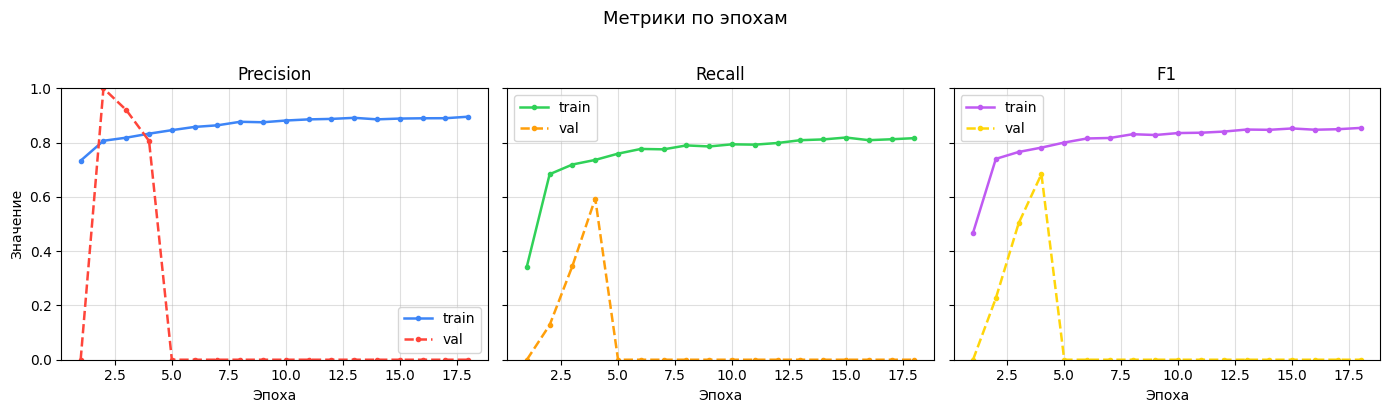

In [47]:
main()

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, precision_recall_curve

def _f1_at_best_threshold(y_true, y_prob):
  """Лучший F1 по PR-кривой + соответствующий порог."""
  prec, rec, thr = precision_recall_curve(y_true, y_prob)
  f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
  i = int(np.nanargmax(f1[:-1]))  # последняя точка кривой не имеет порога
  return float(f1[i]), float(thr[i]), float(prec[i]), float(rec[i])

def evaluate_baseline(name, y_val, p_val, y_test, p_test):
  """PR-AUC на val/test; порог подбирается по val и фиксируется для test."""
  ap_val = average_precision_score(y_val, p_val)
  ap_test = average_precision_score(y_test, p_test)

  _, thr, _, _ = _f1_at_best_threshold(y_val, p_val)
  pred_test = (p_test >= thr).astype(int)
  tp = int(((pred_test == 1) & (y_test == 1)).sum())
  fp = int(((pred_test == 1) & (y_test == 0)).sum())
  fn = int(((pred_test == 0) & (y_test == 1)).sum())
  prec = tp / (tp + fp) if tp + fp else 0.0
  rec = tp / (tp + fn) if tp + fn else 0.0
  f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0

  print(f"{name:<28} val_pr_auc={ap_val:.4f}  test_pr_auc={ap_test:.4f}  "
        f"| test@thr={thr:.3f}: prec={prec:.3f} rec={rec:.3f} f1={f1:.3f}")
  return ap_val, ap_test


def run_baselines(splits: SplitResult, target_raw_col: str = 'target_raw'):
  y_val = splits.val['target'].values
  y_test = splits.test['target'].values

  print(f"Доля позитивов (= PR-AUC случайной модели): "
        f"val={y_val.mean():.4f}  test={y_test.mean():.4f}")
  print('─' * 100)

  # ── 1. Наивное правило: ряд уже выше порога сейчас ────────────────────
  # В качестве "вероятности" берём само текущее значение ряда — для
  # PR-AUC важен только порядок, монотонного признака достаточно.
  evaluate_baseline(
    '1. naive: target_raw[t]',
    y_val, splits.val[target_raw_col].values,
    y_test, splits.test[target_raw_col].values,
  )

  # ── 2. Логистическая регрессия на истории самого ряда ────────────────
  ar_cols = [c for c in splits.train.columns
             if c.startswith(target_raw_col)]  # target_raw + его lag/roll/diff
  print(f"\n2. AR-фичи ({len(ar_cols)}): {ar_cols}\n")

  scaler = StandardScaler().fit(splits.train[ar_cols])
  logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
  logreg.fit(scaler.transform(splits.train[ar_cols]), splits.train['target'])

  evaluate_baseline(
    '2. logreg on AR features',
    y_val, logreg.predict_proba(scaler.transform(splits.val[ar_cols]))[:, 1],
    y_test, logreg.predict_proba(scaler.transform(splits.test[ar_cols]))[:, 1],
  )

  # ── 3. LightGBM на всех признаках ─────────────────────────────────────
  import lightgbm as lgb

  feature_cols = [c for c in splits.train.columns
                  if c not in ['timestamp', 'target']]

  lgbm = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42,
  )
  lgbm.fit(
    splits.train[feature_cols], splits.train['target'],
    eval_set=[(splits.val[feature_cols], y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(100, verbose=False)],
  )

  evaluate_baseline(
    '3. LightGBM (all features)',
    y_val, lgbm.predict_proba(splits.val[feature_cols])[:, 1],
    y_test, lgbm.predict_proba(splits.test[feature_cols])[:, 1],
  )

  # Топ признаков — на чём держится сигнал
  imp = (pd.Series(lgbm.feature_importances_, index=feature_cols)
         .sort_values(ascending=False))
  print('\nТоп-15 признаков LightGBM:')
  print(imp.head(15).to_string())

  return lgbm, imp

In [36]:
! pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 6.4 MB/s  0:00:00 eta 0:00:01
    PyYAML (<=6.*,>=5.*)
            ~~~~^

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [37]:
raw_df = pd.read_excel('extcaland.xlsx')
raw_df = raw_df.rename(columns={'target': 'target_raw'})

TARGET_THRESHOLD = 45.0
FORECAST_HORIZON = 10

df = make_supervised_timeseries_frame(
raw_df,
target_col='target_raw',
time_col='timestamp',
target_threshold=TARGET_THRESHOLD,
forecast_horizon=FORECAST_HORIZON,
lags=(1, 5, 20),
rolling_windows=(20,),
add_current=True,
)

splits = temporal_episode_split(
df,
target_col='target',
time_col='timestamp',
train_episode_size=0.65,
val_episode_size=0.1,
test_episode_size=0.25,
event_max_gap=50,
purge_gap=70,
)

lgbm, importances = run_baselines(splits)

time-series frame: rows=51,617, features=261, target>45.0 at horizon=10, positives=1,335 (2.586%)
positive episodes: 28, event_max_gap=50, positive counts=[30, 40, 3, 67, 24, 10, 67, 1, 24, 16, 4, 36, 33, 32, 30, 7, 16, 6, 2, 104, 29, 709, 13, 2, 15, 8, 6, 1]
---------------------------------------------------------------------------------
Сплит        Строк  % от всех   Дефекты   % дефектов                       Период
---------------------------------------------------------------------------------
Train       26,674       51.7%       446        1.67%  2020-10-19 11:25:08 -> 2020-10-28 18:29:36
Val          2,370        4.6%       133        5.61%  2020-10-28 19:05:15 -> 2020-10-29 14:54:49
Test        22,433       43.5%       690        3.08%  2020-10-29 15:30:28 -> 2020-11-06 11:04:19
purge_gap: 70 строк между соседними сплитами
---------------------------------------------------------------------------------
Доля позитивов (= PR-AUC случайной модели): val=0.0561  test=0.0308
─────